In [1]:
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple
from isofit.configs import configs
from isofit.core.geometry import Geometry

import os
from glob import glob
import logging
import numpy as np
from spectral.io import envi
from spectral.io.envi import read_envi_header
import matplotlib.pyplot as plt
import pickle

from utilities import single_px_retrieval

%matplotlib widget

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

In [10]:
# exploratory single-pixel retrievals for iterative improvements

# single pixels are mean rdn values over representative pixels of each of the three classes:
# white tarp, black tarp, aspen

# update from 7/31: try using avirisng instrument models?
# took 3 aviris_ng files, interpolated to neon wavelengths: channelized uncertaintiy, noise, model discrepancy

In [2]:
# define file paths
home = '/store/carroll/col/2018/'
aspen = home+'test_roi/aspen/'
cal = home+'test_roi/calTarp/'

extra_data = '/store/carroll/col/'

dir_insitu = home+'insitu/'

fp_single_px = '/store/carroll/col/2018/test_roi/single_pxs.pkl'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07828101..2.0].


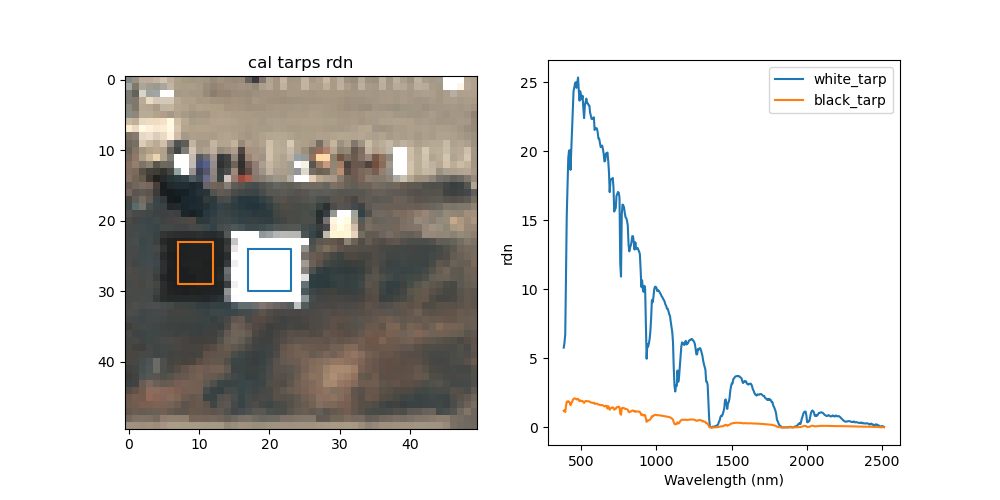

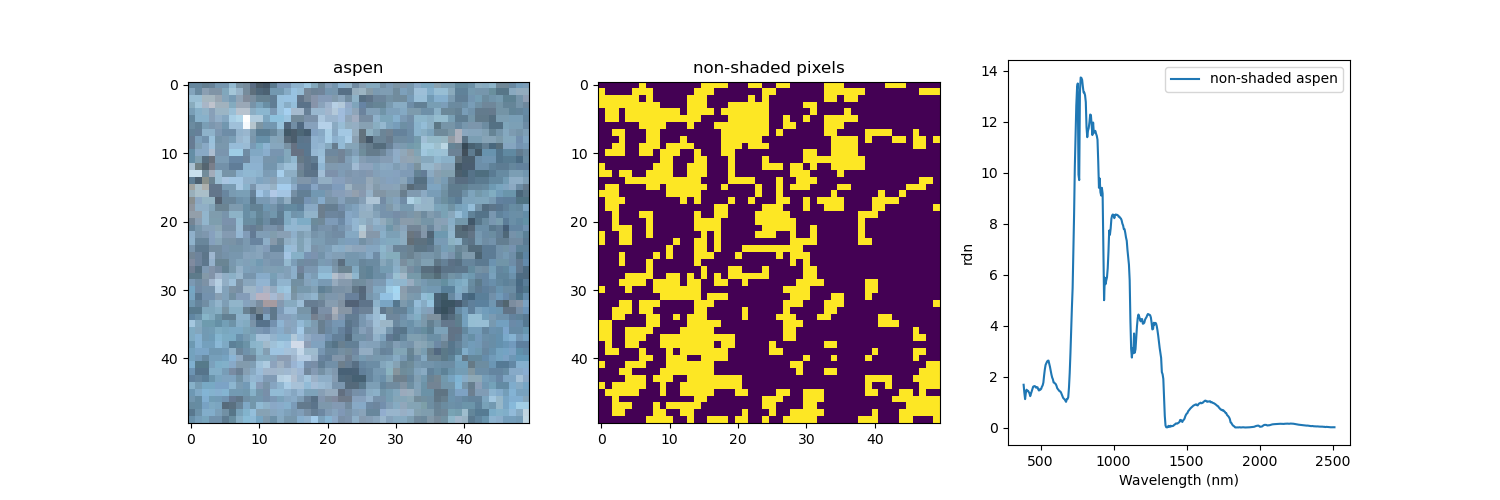

In [6]:
# prepare, vis single px
# visualize full rdn w regions averaged to single pixels
bboxes = {}
bboxes['white_tarp'] = [17,24,23,30]
bboxes['black_tarp'] = [7,23,12,29]

with open(fp_single_px, 'rb') as f:
    single_px = pickle.load(f)
rdn = single_px['rdn']
obs = single_px['obs']
loc = single_px['loc']

flight_cal = 'NIS01_20180611_172310'
flight_aspen = 'NIS01_20180619_172934'

# cal tarps
fig, axs = plt.subplots(ncols=2, figsize=(10,5))
fp = glob(os.path.join(cal, 'subset', '*_rdn.hdr'))[0]
wl = [float(x) for x in read_envi_header(fp)['wavelength']]
rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
axs[0].imshow(rgb / np.max(rgb, axis=(0, 1))*2)
for k, (minx, miny, maxx, maxy) in bboxes.items():
    x = [minx, maxx, maxx, minx, minx]
    y = [miny, miny, maxy, maxy, miny]
    axs[0].plot(x, y, label=k)
axs[0].set_title('cal tarps rdn')
axs[1].plot(wl, rdn[flight_cal]['white_tarp'], label='white_tarp')
axs[1].plot(wl, rdn[flight_cal]['black_tarp'], label='black_tarp')
axs[1].legend()
axs[1].set_xlabel('Wavelength (nm)')
axs[1].set_ylabel('rdn')
plt.show()

# aspen
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
fp = glob(os.path.join(home, 'test_roi', 'aspen', 'subset', '*_rdn.hdr'))[0]
rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
axs[0].imshow(rgb / np.max(rgb, axis=(0, 1)))
axs[0].set_title('aspen')
lit = np.sum(rgb, axis=2)
valid = lit > 5
axs[1].imshow(valid)
axs[1].set_title('non-shaded pixels')
axs[2].plot(wl, rdn[flight_aspen]['aspen'], label='non-shaded aspen')
axs[2].legend()
axs[2].set_xlabel('Wavelength (nm)')
axs[2].set_ylabel('rdn')
plt.show()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 3721 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;

// global attributes:
	:RT_mode = transm ;
	:ISOFIT version = 3.5.0 ;
	:ISOFIT status = success ;
	:subset = {'AOT550': None, 'H2OSTR': None} ;
}

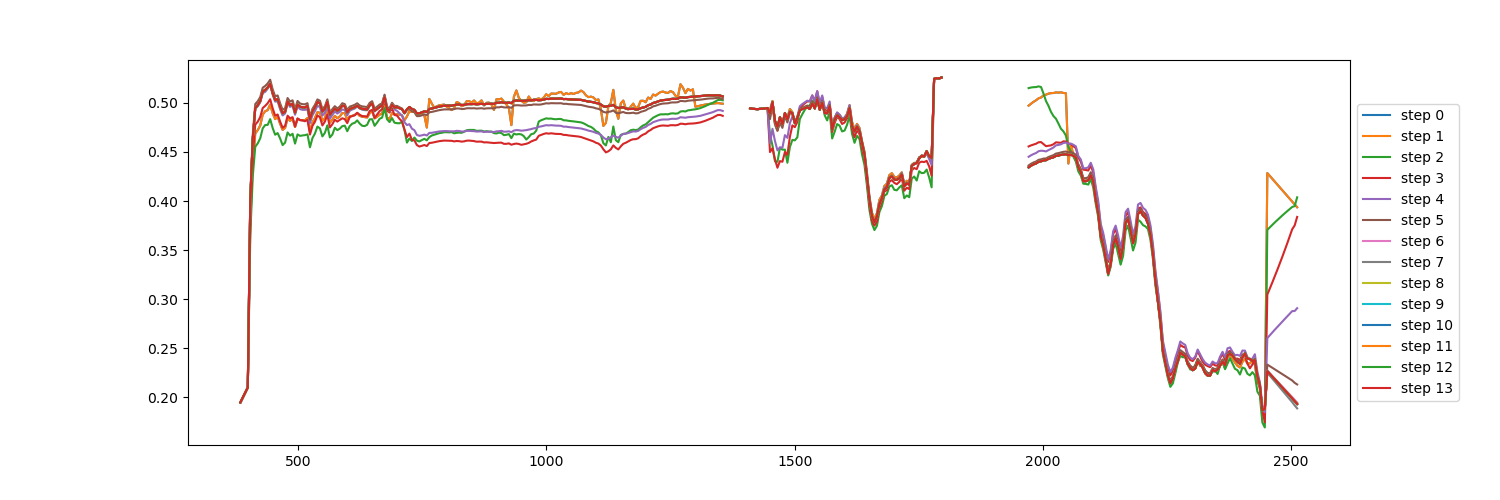

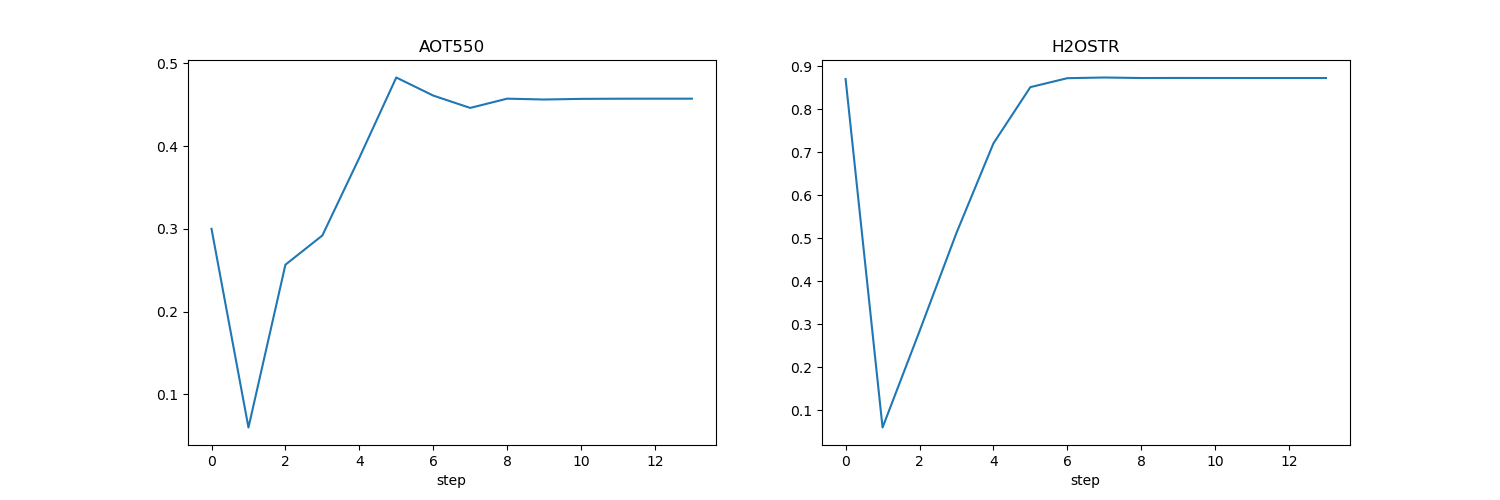

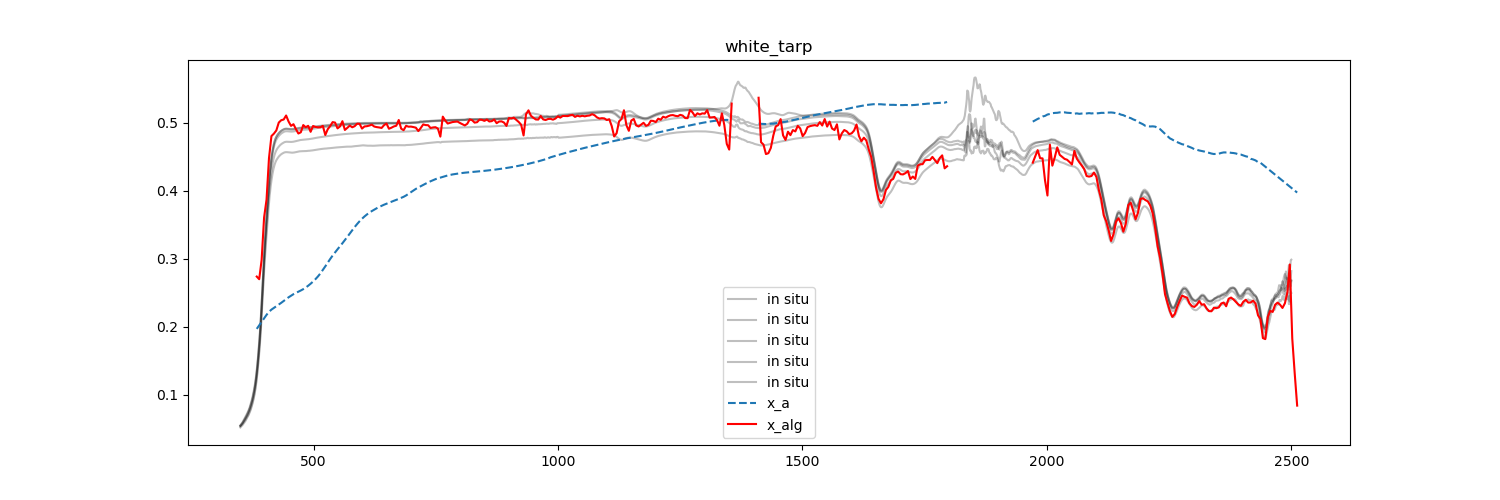

In [7]:
# white tarp

k = 'white_tarp'
fol = cal

# load, update config file
fp = glob(os.path.join(fol, '*', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat')
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]

# borrow the avirisng instrument model, updated to neon wavelengths?
config.forward_model.instrument.parametric_noise_file = extra_data + 'avirisng_noise_neon.txt'
config.forward_model.instrument.integrations = 2 ## post-flight report doesn't state explicitly, but this is a guess given:
    # aircraft speed = 50 m/s
    # frame rate = 100 frames/s (Hz)
    # distance per frame = 50 m/s / 100 frames / s = 0.5 m / frame ... 2 frames per pixel?
config.forward_model.instrument.unknowns.channelized_radiometric_uncertainty_file = extra_data + 'avirisng_systematic_error_neon.txt'
config.forward_model.model_discrepancy_file = extra_data + 'avirisng_model_discrepancy_neon.mat'

# # run retrieval
x_RT, x_alg, coeffs, xa, wl = single_px_retrieval(config, rdn[flight_cal][k], obs[flight_cal][k], loc[flight_cal][k])

# final rfl solution w/ in situ
fps = glob(os.path.join(dir_insitu, f'KBDU_*white', 'Data', f'KBDU_*white_Refl.dat'))
fig = plt.figure(figsize=(15,5))
for fp in fps:
    in_situ = np.genfromtxt(fp, skip_header=3)
    plt.plot(in_situ[:,0], in_situ[:,1], label=f'in situ',c='black', alpha=0.25)
plt.plot(wl, xa, label='x_a', ls='--')
plt.plot(wl, x_alg, label='x_alg', c='red')
plt.title(f'{k}')
plt.legend()
plt.show()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 3721 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;

// global attributes:
	:RT_mode = transm ;
	:ISOFIT version = 3.5.0 ;
	:ISOFIT status = success ;
	:subset = {'AOT550': None, 'H2OSTR': None} ;
}

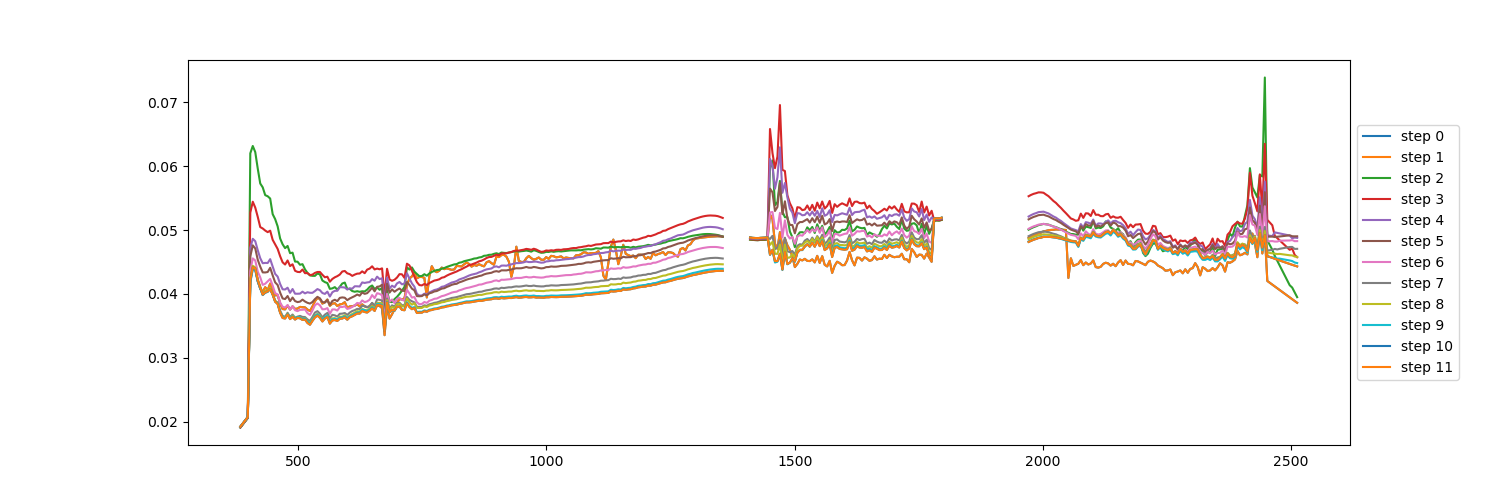

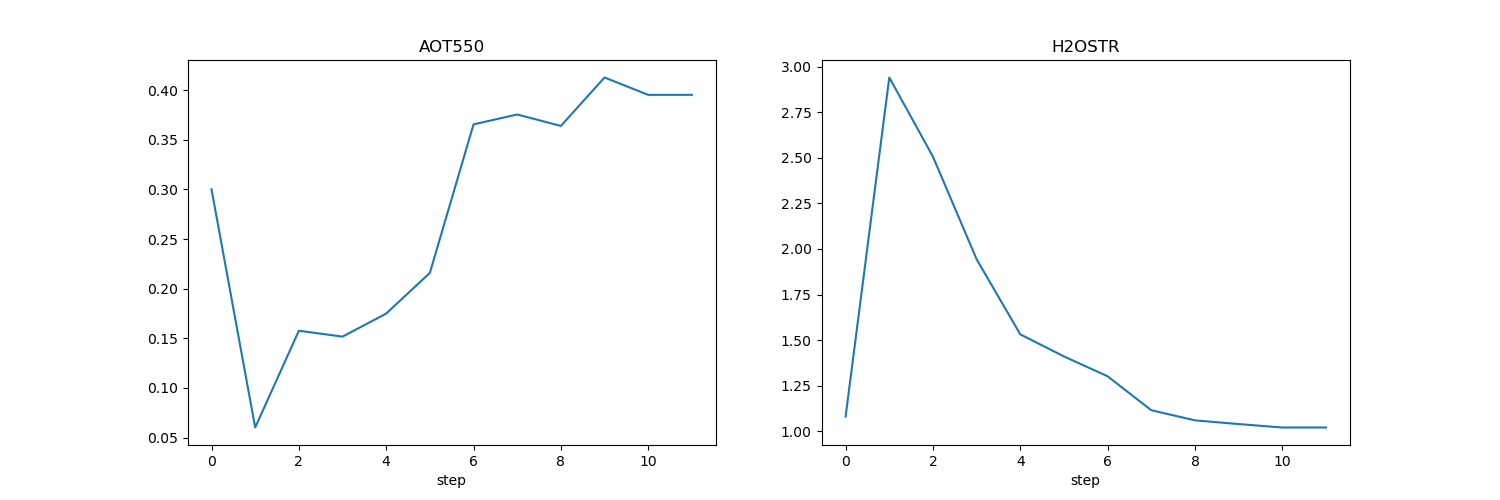

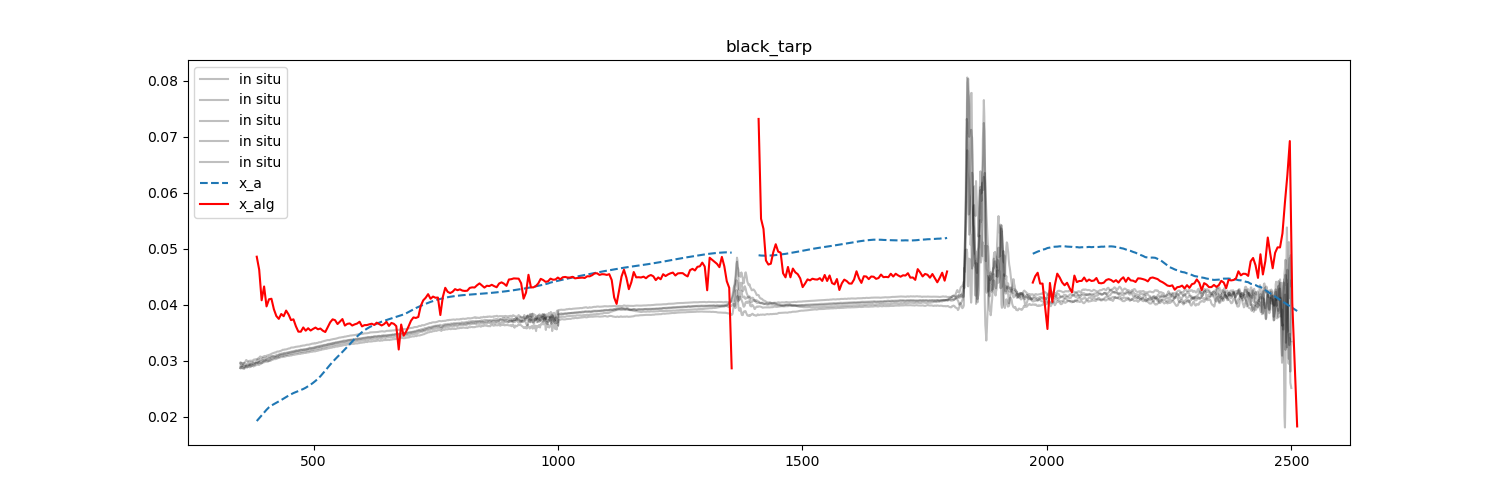

In [8]:
# black tarp

k = 'black_tarp'
fol = cal

# load, update config file
fp = glob(os.path.join(fol, '*', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat') # different from what was used in apply_oe!
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]

# borrow the avirisng instrument model, updated to neon wavelengths?
config.forward_model.instrument.parametric_noise_file = extra_data + 'avirisng_noise_neon.txt'
config.forward_model.instrument.integrations = 2 ## post-flight report doesn't state explicitly, but this is a guess given:
    # aircraft speed = 50 m/s
    # frame rate = 100 frames/s (Hz)
    # distance per frame = 50 m/s / 100 frames / s = 0.5 m / frame ... 2 frames per pixel?
config.forward_model.instrument.unknowns.channelized_radiometric_uncertainty_file = extra_data + 'avirisng_systematic_error_neon.txt'
config.forward_model.model_discrepancy_file = extra_data + 'avirisng_model_discrepancy_neon.mat'

# run retrieval
x_RT, x_alg, coeffs, xa, wl = single_px_retrieval(config, rdn[flight_cal][k], obs[flight_cal][k], loc[flight_cal][k])

# final rfl solution w/ in situ
fps = glob(os.path.join(dir_insitu, f'KBDU_*black', 'Data', f'KBDU_*black_Refl.dat'))
fig = plt.figure(figsize=(15,5))
for fp in fps:
    in_situ = np.genfromtxt(fp, skip_header=3)
    plt.plot(in_situ[:,0], in_situ[:,1], label=f'in situ',c='black', alpha=0.25)
plt.plot(wl, xa, label='x_a', ls='--')
plt.plot(wl, x_alg, label='x_alg', c='red')
plt.title(f'{k}')
plt.legend()
plt.show()

INFO:root:Loading config file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet_20250731/config/NIS01_20180619_172934_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/2018/test_roi/aspen/NIS01_20180619_172934_sRTMnet_20250731/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/luts.py:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


xarray.Dataset {
dimensions:
	wl = 426 ;
	point = 3721 ;

variables:
	float64 wl(wl) ;
	float64 coszen() ;
	float64 solzen() ;
	float64 fwhm(wl) ;
	float64 solar_irr(wl) ;
	float64 rhoatm(point, wl) ;
	float64 sphalb(point, wl) ;
	float64 transm_down_dir(point, wl) ;
	float64 transm_down_dif(point, wl) ;
	float64 transm_up_dir(point, wl) ;
	float64 transm_up_dif(point, wl) ;
	float64 thermal_upwelling(point, wl) ;
	float64 thermal_downwelling(point, wl) ;
	float64 dir-dir(point, wl) ;
	float64 dif-dir(point, wl) ;
	float64 dir-dif(point, wl) ;
	float64 dif-dif(point, wl) ;
	object point(point) ;
	float64 AOT550(point) ;
	float64 H2OSTR(point) ;

// global attributes:
	:RT_mode = transm ;
	:subset = {'AOT550': None, 'H2OSTR': None} ;
}

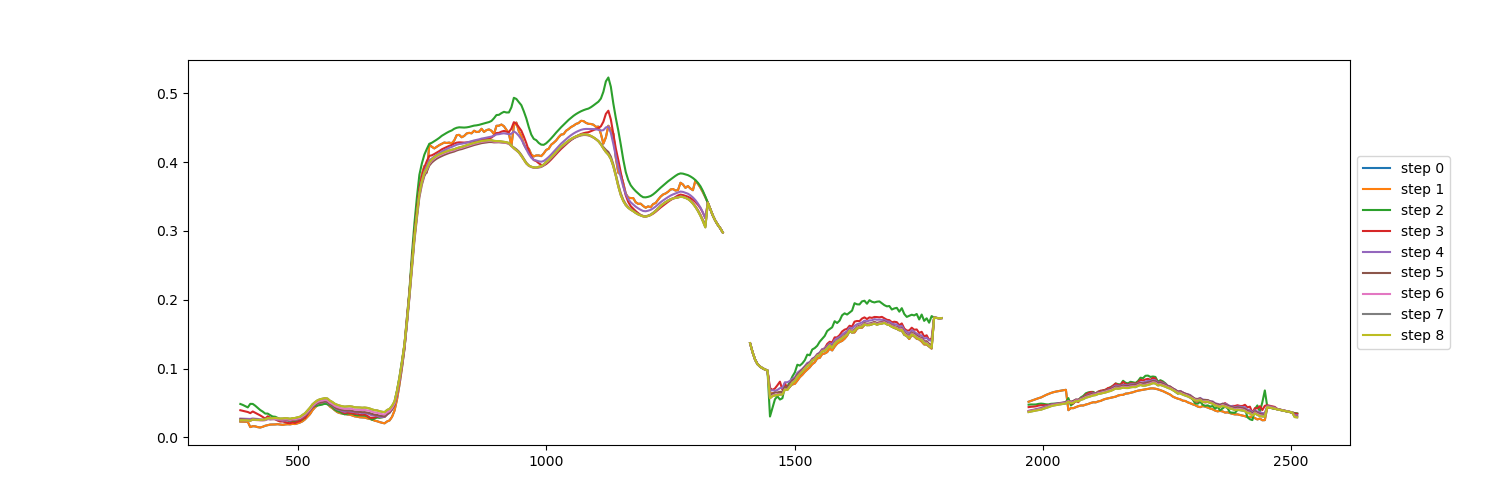

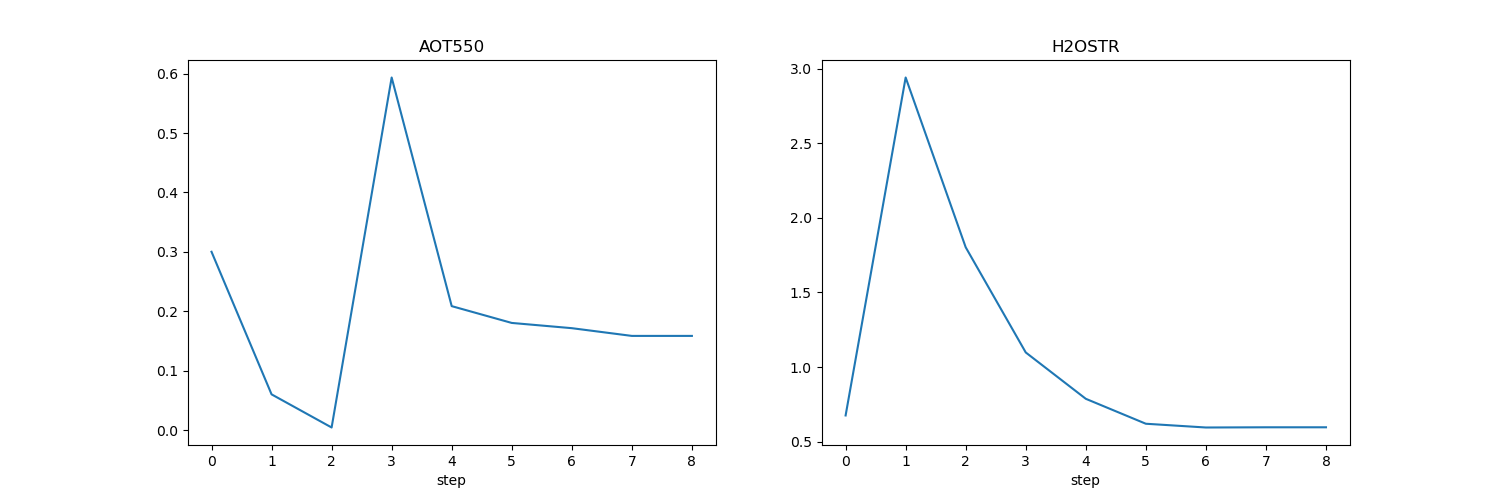

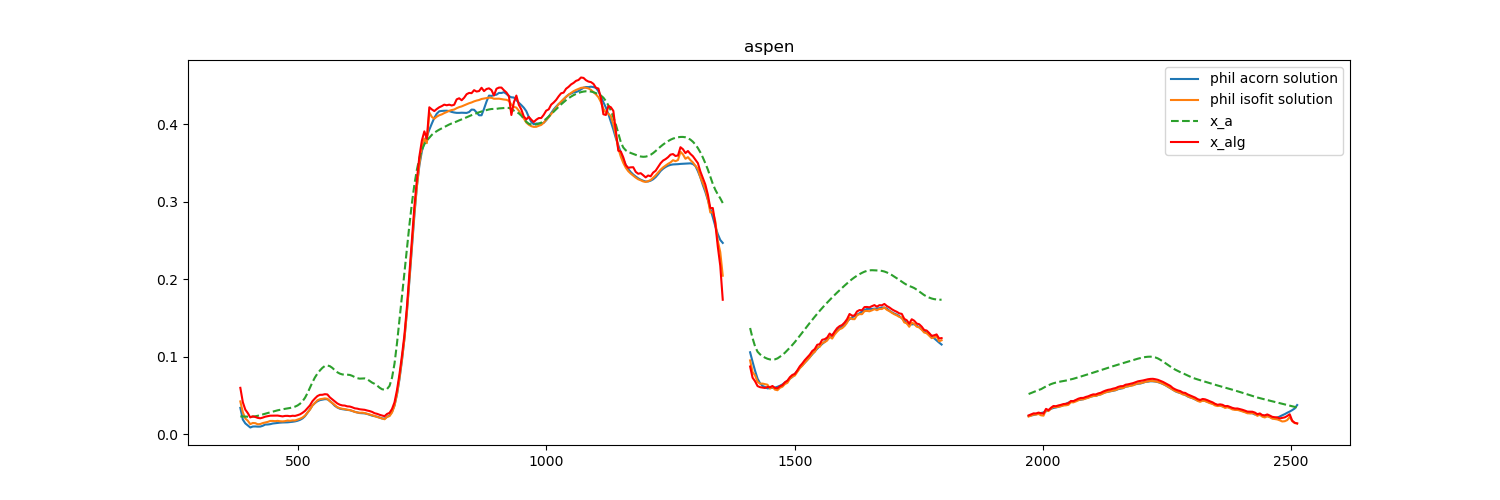

In [9]:
# aspen

k = 'aspen'
fol = aspen

# load, update config file
fp = glob(os.path.join(fol, '*', 'config', '*_isofit.json'))[0]
config = configs.create_new_config(fp)
config.forward_model.surface.surface_file = os.path.join(home, 'test_roi/surface_20240103_avirii_20250730.mat') # different from what was used in apply_oe!
config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', '*_rdn'))[0]
config.input.obs_file = glob(os.path.join(fol, 'subset', '*_obs'))[0]
config.input.loc_file = glob(os.path.join(fol, 'subset', '*_igm'))[0]

# borrow the avirisng instrument model, updated to neon wavelengths?
config.forward_model.instrument.parametric_noise_file = extra_data + 'avirisng_noise_neon.txt'
config.forward_model.instrument.integrations = 2 ## post-flight report doesn't state explicitly, but this is a guess given:
    # aircraft speed = 50 m/s
    # frame rate = 100 frames/s (Hz)
    # distance per frame = 50 m/s / 100 frames / s = 0.5 m / frame ... 2 frames per pixel?
config.forward_model.instrument.unknowns.channelized_radiometric_uncertainty_file = extra_data + 'avirisng_systematic_error_neon.txt'
config.forward_model.model_discrepancy_file = extra_data + 'avirisng_model_discrepancy_neon.mat'

# run retrieval
x_RT, x_alg, coeffs, xa, wl = single_px_retrieval(config, rdn[flight_aspen][k], obs[flight_aspen][k], loc[flight_aspen][k])

# compare w Phil retrievals (original acorn, isofit)
rfl_acorn = envi.open(aspen + '/subset/min_phase_refl.hdr').open_memmap(interleave='bip').copy()/10000
rfl_isofit = envi.open(aspen + 'subset/min_phase_isofit_rfl.hdr').open_memmap(interleave='bip').copy()
rfl_acorn[valid==False,:] = np.nan
rfl_isofit[valid==False,:] = np.nan
rfl_acorn = np.nanmean(rfl_acorn, axis=(0, 1))
rfl_isofit = np.nanmean(rfl_isofit, axis=(0, 1))

fig = plt.figure(figsize=(15,5))
plt.plot(wl, rfl_acorn, label='phil acorn solution')
plt.plot(wl, rfl_isofit, label='phil isofit solution')
plt.plot(wl, xa, label='x_a', ls='--')
plt.plot(wl, x_alg, label='x_alg', c='red')
plt.title(f'{k}')
plt.legend()
plt.show()